In [1]:
%matplotlib widget
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import torch
from gencase import *
from util import visualize, sampleParticles, generateInitialVariables, SamplingScheme
from sample import smoothState, addNoise, populateCGrid, populateUGrid, smoothValues
from util import plotState, plotInitialState
from simulation import runSimulation
from util import getCurrentTimestamp
from argparse import ArgumentParser

import h5py
from dataset import *

In [2]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

In [3]:
datasetProperties = DataSetProperties(
    skipInitialSteps= 0,
    skipFinalSteps= 0,
    temporalCoarseGrainingRate= 1,
    unrollLength= 1,
    historyLength= 0
)

simFolder = 'output'
files, S, T, N, Nx, Ny = getDatasetProperties(simFolder)
print(f'Dataset has S={S} samples, T={T} timesteps, N={N} particles, Nx={Nx}, Ny={Ny}')

Dataset has S=3 samples, T=1025 timesteps, N=16384 particles, Nx=128, Ny=128


In [4]:
dataset = Dataset(datasetProperties, files, T, device)
batchSize = 1

datasetLoader = torch.utils.data.DataLoader(dataset, batch_size=batchSize, shuffle=True)
datasetIter = iter(datasetLoader)
batch = next(datasetIter)

0it [00:00, ?it/s]

In [12]:
waveSystem, config, integrator, dt, history, trajectory, current = batchToSimulation(next(datasetIter))

0it [00:00, ?it/s]

0it [00:00, ?it/s]

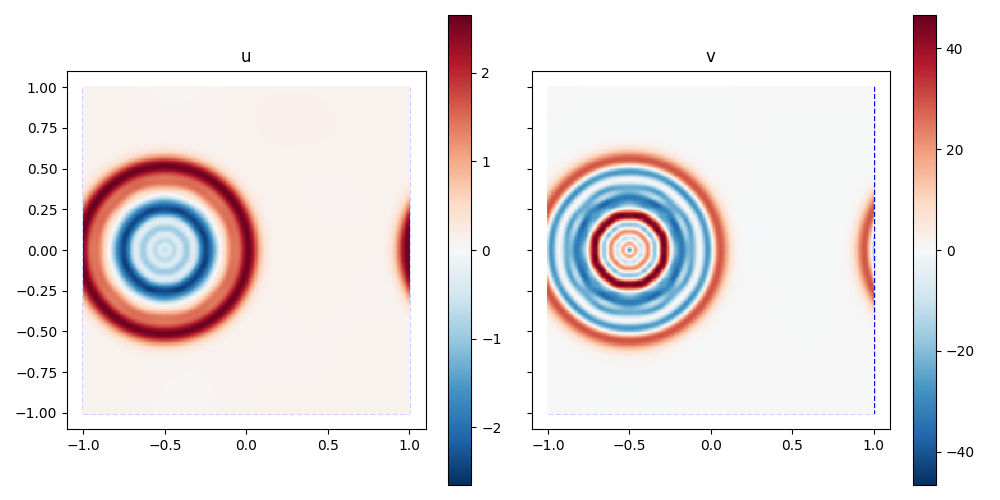

In [13]:
fig, axis, uPlot, vPlot, cPlot, dampPlot = plotState(
    waveSystem.systemState,
    waveSystem.waveState,
    config, config['kernel'],
    markerSize = 0.5,
    plotGrid = True,
    plotCD = False)
# fig.savefig(f'output/{folderName}/initial_state.png', dpi = args.figureDpi)

In [ ]:
u = waveSystem.waveState.u
v = waveSystem.waveState.v
c = waveSystem.waveState.c
damp = waveSystem.waveState.damping

# u.requires_grad = True
# v.requires_grad = True

waveSystem.waveState.u = u
waveSystem.waveState.v = v
waveSystem.waveState.c = c
waveSystem.waveState.damping = damp

In [15]:
eulerIntegrator = getIntegrator(IntegrationSchemeType.explicitEuler)
RK4Integrator = getIntegrator(IntegrationSchemeType.rungeKutta4)

In [16]:
waveSystemNext, updates =  eulerIntegrator.function(
    waveSystem,
    dt = dt,
    f = waveSystemFunction,
    verbose = False,
    config = config,
)

In [17]:
simResultU = waveSystemNext.waveState.u

print(f'waveSystemNext.waveState.u shape: {simResultU.shape}, dtype: {simResultU.dtype}, device: {simResultU.device}')
print(f'Value: {simResultU}')

loss = torch.nn.MSELoss()(simResultU, trajectory[0,:,0])
print(f'Loss: {loss.item()}')

loss.backward()

waveSystemNext.waveState.u shape: torch.Size([16384]), dtype: torch.float32, device: cuda:0
Value: tensor([0.0964, 0.0957, 0.0950,  ..., 0.0974, 0.0969, 0.0963], device='cuda:0',
       grad_fn=<IndexPutBackward0>)
Loss: 3.0088090170465875e-06


In [18]:
simResultU = waveSystemNext.waveState.u.shape
trajectoryU = trajectory[0,:,0]

print(f'waveSystemNext.waveState.u shape: {simResultU}')
print(f'trajectoryU shape: {trajectoryU.shape}')
print(f'close: {torch.allclose(waveSystemNext.waveState.u.cpu(), trajectory[0,:,0].cpu(), atol=1e-5)}')

waveSystemNext.waveState.u shape: torch.Size([16384])
trajectoryU shape: torch.Size([16384])
close: False
